## Multiple Schemas  

generally all the nodes uses the same schema, but somethimes require different schemas

**PRIVATE STATE** 

[Privates State DOC](https://docs.langchain.com/oss/python/langgraph/use-graph-api#pass-private-state-between-nodes)

useful for anything needed as part of intermediate working logic of the graph - not relevet for the overall graph output.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
BASE_URL = os.getenv('OPENAI_BASE_URL')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' # Set the LangSmith project name

In [2]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    api_key= API_KEY,
    base_url = BASE_URL,
    model = 'gpt-5.1'
)

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

c:\Data\Codes\AgenticAITraining\Lanchain_LangGraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
class OverallState(TypedDict):
    destination: str
    final_itineary: str

class PrivateState(TypedDict):
    api_data: dict

def fetch_flight_data(state: OverallState) -> PrivateState:
    print('---Featching the Raw Flight Data - as internal step---')
    return {
        'api_data': {
            'flight_id': 'FL231',
            'price': 256,
            'gate': 'D12',
            'status': 'confirmed',
            'seats': 'available'
        }
    }

def summarize_iteineary(state: PrivateState) -> OverallState:
    print('--- Summarizing the User ---')
    raw = state['api_data']
    itinerary = f'Flight {raw['flight_id']} is {raw['status']} at {raw['price']}'
    return {'final_itineary': itinerary}

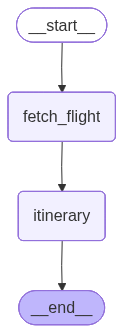

In [8]:
builder = StateGraph(OverallState)

builder.add_node("fetch_flight", fetch_flight_data)
builder.add_node("itinerary", summarize_iteineary)

builder.add_edge(START, "fetch_flight")
builder.add_edge("fetch_flight", "itinerary")
builder.add_edge("itinerary", END)

graph = builder.compile()
graph

In [9]:
inputs = {'destination': 'Paris'}
result = graph.invoke(inputs)

print('---Final Result----')
print(result) 

---Featching the Raw Flight Data - as internal step---
--- Summarizing the User ---
Flight FL231 is confirmed at 256
---Final Result----
{'destination': 'Paris', 'final_itineary': 'Flight FL231 is confirmed at 256'}


In [12]:
for chunk in graph.stream({"destination": "London"}, stream_mode="updates"):
    print(chunk)

---Featching the Raw Flight Data - as internal step---
{'fetch_flight': {'api_data': {'flight_id': 'FL231', 'price': 256, 'gate': 'D12', 'status': 'confirmed', 'seats': 'available'}}}
--- Summarizing the User ---
Flight FL231 is confirmed at 256
{'itinerary': {'final_itineary': 'Flight FL231 is confirmed at 256'}}


The API data is only included in Privte State not in Overall State

### Input Output schema

We can have seprate input and output schema [Docs](https://docs.langchain.com/oss/python/langgraph/use-graph-api#define-input-and-output-schemas)

In [13]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [17]:
class Overall(TypedDict):
    question: str
    answer: str 
    notes: str # -> Acts as internal memory

def check_order_status(state: Overall):
    print('Thinking Checking database')
    return {
        'notes': 'Order #42: Pepperoni Pizza, Status: Out for Delivery',
        'answer': "Checking your  order now:"
    }

def final_response(state: OverallState):
    print("Answering writing to user")
    status_info = state['notes']
    return {
        'answer': f'Good News! {status_info}. It should be there in 4 mins'
    }

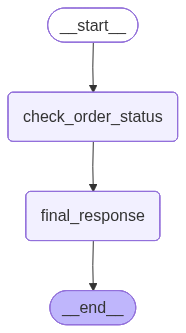

In [19]:
builder = StateGraph(Overall)

builder.add_node("check_order_status", check_order_status)
builder.add_node("final_response", final_response)

builder.add_edge(START, "check_order_status")
builder.add_edge("check_order_status", "final_response")
builder.add_edge("final_response", END)

graph = builder.compile()
graph

In [21]:
# --- Execution ---
inputs = {"question": "Where is my pizza?"}
result = graph.invoke(inputs)

print("\n--- Final Result ---")
print(result)
print(result.keys())

Thinking Checking database
Answering writing to user

--- Final Result ---
{'question': 'Where is my pizza?', 'answer': 'Good News! Order #42: Pepperoni Pizza, Status: Out for Delivery. It should be there in 4 mins', 'notes': 'Order #42: Pepperoni Pizza, Status: Out for Delivery'}
dict_keys(['question', 'answer', 'notes'])


Here we are also getting the Notes in the output schema, which is just there for the internal memory

In [22]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class InputState(TypedDict):
    question: str
class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    answer: str
    notes: str # For internal Stroage

def check_order_status(state: InputState) -> OverallState:
    print("--- Thinking: Checking Database ---")
    return {
        "notes": "Order #42: Pepperoni Pizza, Status: Out for Delivery",
        "answer": "Checking your order now..." 
    }


def final_response(state: OverallState) -> OutputState:
    print("--- Answering: Writing to User ---")
    status_info = state['notes']
    return {"answer": f"Good news! {status_info}. It should be there in 5 minutes!"}


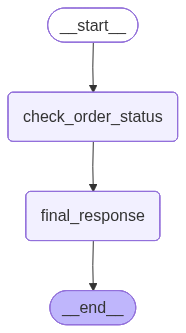

In [23]:
builder = StateGraph(OverallState,input_schema=InputState, output_schema=OutputState)

builder.add_node("check_order_status", check_order_status)
builder.add_node("final_response", final_response)

builder.add_edge(START, "check_order_status")
builder.add_edge("check_order_status", "final_response")
builder.add_edge("final_response", END)

graph = builder.compile()
graph

In [25]:
inputs = {"question": "Where is my pizza?"}
result = graph.invoke(inputs)

print("\n--- Final Result ---")
print(result)

--- Thinking: Checking Database ---
--- Answering: Writing to User ---

--- Final Result ---
{'answer': 'Good news! Order #42: Pepperoni Pizza, Status: Out for Delivery. It should be there in 5 minutes!'}
